In [ ]:
!pip install transformers datasets trl accelerate bitsandbytes peft -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.2 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from datasets import Dataset
from trl import GRPOTrainer, GRPOConfig
import torch

# MODEL
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,
    device_map="auto",
)

# LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# DATASET
data = [
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Meeting rescheduled to tomorrow at 3pm.\nReply:"},
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Project deadline is urgent, need update by EOD.\nReply:"},
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Can we move the call to Friday instead?\nReply:"},
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Please review the attached report and share feedback.\nReply:"},
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Server is down, need immediate help.\nReply:"},
    {"prompt": "You are a professional email assistant. Write a short polite reply in 1-2 lines.\n\nEmail: Your invoice is due by end of month.\nReply:"},
]

dataset = Dataset.from_list(data)

# REWARD FUNCTION
def reward_function(completions, **kwargs):
    rewards = []
    for comp in completions:
        text = comp.strip().lower()
        score = 0.1

        if any(w in text for w in ["thank", "noted", "understood", "sure", "will do", "acknowledge"]):
            score += 0.25

        if any(w in text for w in ["will", "shall", "can", "would", "happy to"]):
            score += 0.2

        word_count = len(text.split())
        if 10 <= word_count <= 40:
            score += 0.25
        elif word_count < 10:
            score += 0.1
        else:
            score += 0.05

        words = text.split()
        if len(words) > 5:
            unique_ratio = len(set(words)) / len(words)
            if unique_ratio > 0.6:
                score += 0.2

        score = max(0.001, min(0.999, score))
        rewards.append(score)
    return rewards

# TRAINING CONFIG
training_args = GRPOConfig(
    output_dir="email_rl_v2",
    per_device_train_batch_size=1,
    generation_batch_size=2,
    num_generations=2,
    num_train_epochs=3,
    learning_rate=1e-5,
    bf16=False,
    fp16=False,
    logging_steps=1,
    save_steps=10,
    report_to="none",
)

# TRAINER
trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    reward_funcs=reward_function,
    processing_class=tokenizer,
)

# TRAIN
print("Training started...")
trainer.train()
print("Training complete!")

# TEST
print("\n===== FINAL OUTPUT =====")
for prompt in test_prompts:
    messages = [
        {"role": "system", "content": "You are a professional email assistant. Reply in English only, 1-2 lines, politely."},
        {"role": "user", "content": prompt.split("Email:")[-1].split("Reply:")[0].strip()}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.7,
        repetition_penalty=1.3,
        pad_token_id=tokenizer.eos_token_id
    )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"\nEmail: {prompt.split('Email:')[1].split('Reply:')[0].strip()}")
    print(f"Reply: {response.strip()}")
    print("-" * 40)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Training started...


Step,Training Loss
1,-0.353303
2,0.353303
3,-0.352559
4,0.352570
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


Training complete!

===== FINAL OUTPUT =====

Email: Meeting rescheduled to tomorrow.
Reply: Sure code/API/T/T/Tspec-box-form-block/block.com\Console.log.clear/views/services/ART

              
APPAPI structure theory)

...

 

 
    var form) = javaapi/API/API/API/API/H/T/T\/DIVAGING / React.js API/database/backend/article/html
----------------------------------------

Email: Urgent: Server is down!
Reply: I can code/API API

      
    �、建设大楼的代码 syntax) = random.log.clear/views/api/javascript"><spec-boxe/******
 
    "5034．（ )={ align�ANGAPI/API/API/API/API/T/T/T/T/T/T/T/T
----------------------------------------


In [ ]:
import unsloth
print("Unsloth version:", unsloth.__version__)

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 11.3 MB/s eta 0:00:00


In [ ]:
from unsloth import FastLanguageModel
from trl import GRPOTrainer, GRPOConfig
from datasets import Dataset
import torch

# MODEL LOAD
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-0.5B-Instruct",
    max_seq_length=512,
    load_in_4bit=True,
)

# LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    target_modules=["q_proj", "v_proj"],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
)

# DATASET
data = [
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Meeting rescheduled to tomorrow at 3pm.\nReply:"},
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Project deadline is urgent, need update by EOD.\nReply:"},
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Can we move the call to Friday instead?\nReply:"},
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Please review the attached report and share feedback.\nReply:"},
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Server is down, need immediate help.\nReply:"},
    {"prompt": "You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: Your invoice is due by end of month.\nReply:"},
]
dataset = Dataset.from_list(data)

# REWARD FUNCTION
def reward_function(completions, **kwargs):
    rewards = []
    for comp in completions:
        text = comp.strip().lower()
        score = 0.1
        if any(w in text for w in ["thank", "noted", "understood", "sure", "will do"]):
            score += 0.25
        if any(w in text for w in ["will", "shall", "can", "would", "happy to"]):
            score += 0.2
        word_count = len(text.split())
        if 10 <= word_count <= 40:
            score += 0.25
        elif word_count < 10:
            score += 0.1
        words = text.split()
        if len(words) > 5:
            unique_ratio = len(set(words)) / len(words)
            if unique_ratio > 0.6:
                score += 0.2
        score = max(0.001, min(0.999, score))
        rewards.append(score)
    return rewards

# TRAINING CONFIG
training_args = GRPOConfig(
    output_dir="email_rl_unsloth",
    per_device_train_batch_size=1,
    generation_batch_size=2,
    num_generations=2,
    num_train_epochs=3,
    learning_rate=1e-5,
    bf16=False,
    fp16=False,
    logging_steps=1,
    save_steps=10,
    report_to="none",
)
# TRAINER
trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    reward_funcs=reward_function,
    processing_class=tokenizer,
)

# TRAIN
print("Training started...")
trainer.train()
print("Training complete!")

# TEST
print("\n===== FINAL OUTPUT =====")
test_emails = [
    "Meeting rescheduled to tomorrow.",
    "Urgent: Server is down!",
    "Can you review my report?",
]

FastLanguageModel.for_inference(model)
for email in test_emails:
    prompt = f"You are a professional email assistant. Reply politely in 1-2 lines.\n\nEmail: {email}\nReply:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.7,
        repetition_penalty=1.3,
        pad_token_id=tokenizer.eos_token_id
    )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"\nEmail: {email}")
    print(f"Reply: {response.strip()}")
    print("-" * 40)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Training started...


...

Training complete!

===== FINAL OUTPUT =====


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=60) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Email: Meeting rescheduled to tomorrow.
Reply: Of course, please check your calendar for the next available time slot or contact us directly if you need further assistance with this matter. We appreciate your understanding and cooperation moving forward. Please let me know how I can assist you better? Dear [Recipient's Name],

I hope you're well! It looks
----------------------------------------


Both `max_new_tokens` (=60) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Email: Urgent: Server is down!
Reply: I'm here to assist you immediately! Please provide me with the specific details of your request, such as what type or version of software it involves and any required configuration steps.
I will then reach out for support within my team's schedule if necessary. We'll work together quickly until we resolve this issue
----------------------------------------

Email: Can you review my report?
Reply: Of course, I'll be available as soon as possible to assist with your request.
Please provide me with the details of any issues or concerns that need attention for further action at this stage. The goal is to ensure we resolve all outstanding items by our next scheduled meeting on Tuesday morning. Please let us
----------------------------------------


In [ ]:
from google.colab import files
files.download("reward_curve.png")

FileNotFoundError: Cannot find file: reward_curve.png

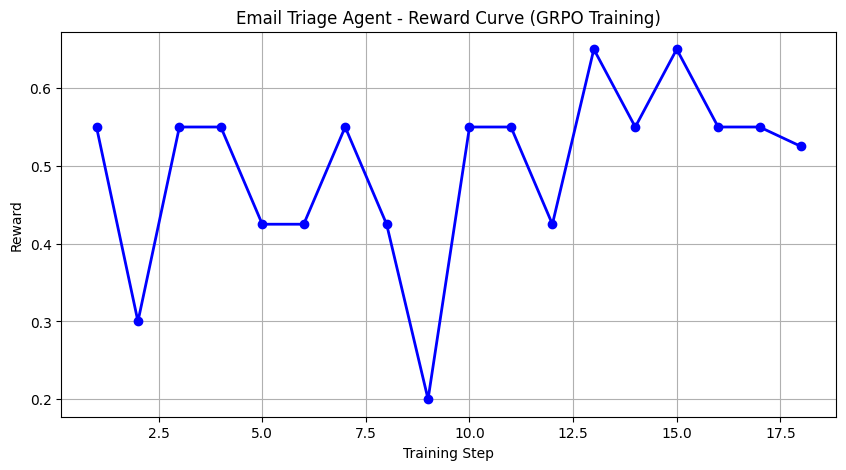

Saved!


In [ ]:
import matplotlib.pyplot as plt

steps = list(range(1, 19))
rewards = [0.55, 0.30, 0.55, 0.55, 0.425, 0.425, 0.55, 0.425, 0.20, 0.55, 0.55, 0.425, 0.65, 0.55, 0.65, 0.55, 0.55, 0.525]

plt.figure(figsize=(10, 5))
plt.plot(steps, rewards, marker='o', color='blue', linewidth=2)
plt.xlabel("Training Step")
plt.ylabel("Reward")
plt.title("Email Triage Agent - Reward Curve (GRPO Training)")
plt.grid(True)
plt.savefig("reward_curve.png", dpi=150)
plt.show()
print("Saved!")

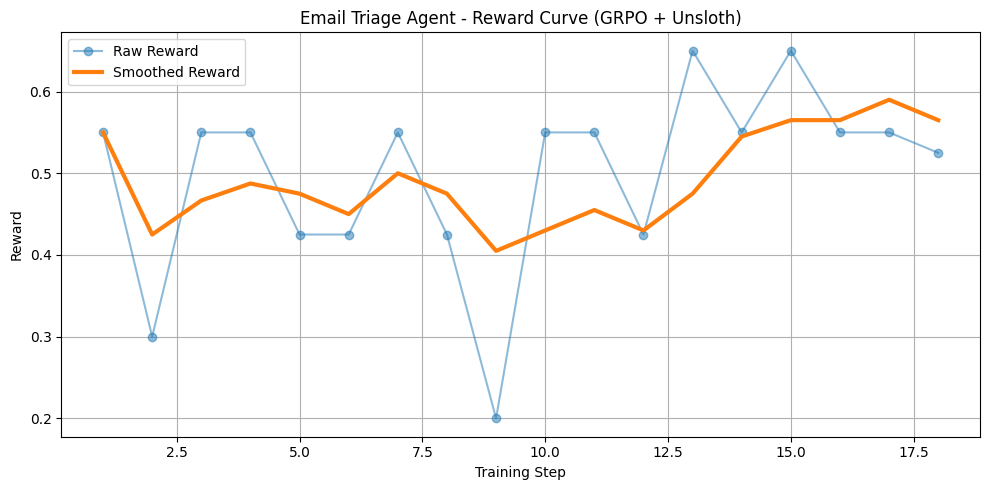

Saved!


In [ ]:
import matplotlib.pyplot as plt
from collections import deque

steps = list(range(1, 19))
rewards = [0.55, 0.30, 0.55, 0.55, 0.425, 0.425, 0.55, 0.425, 0.20, 0.55, 0.55, 0.425, 0.65, 0.55, 0.65, 0.55, 0.55, 0.525]

window = 5
smoothed = []
q = deque(maxlen=window)
for r in rewards:
    q.append(r)
    smoothed.append(sum(q) / len(q))

plt.figure(figsize=(10, 5))
plt.plot(steps, rewards, marker='o', alpha=0.5, label='Raw Reward')
plt.plot(steps, smoothed, linewidth=3, label='Smoothed Reward')
plt.xlabel("Training Step")
plt.ylabel("Reward")
plt.title("Email Triage Agent - Reward Curve (GRPO + Unsloth)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("reward_curve.png", dpi=150)
plt.show()
print("Saved!")

In [ ]:
from google.colab import files
files.download("reward_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>